In [1]:
from datasets import load_dataset
from attention_nn.dataset import get_all_sentences, build_tokenizer
import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES
from configurations.data_config import make_params_dict , load_data , save_fig

apply_general_styles()

/u/c/cerazova/miniconda3/envs/transf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Analyze dataset

In [41]:
dataset_sizes = [5000,10000,15000,20000,2119719]

# dataset_sizes = np.array([100,500,1000])


results = {}


for dataset_size in dataset_sizes:
    
    print(f'\nProcessing dataset size: {dataset_size}')

    raw_dataset = load_dataset("roneneldan/TinyStories",split=f"train[:{dataset_size}]")
    len_dataset = len(raw_dataset)
    tokenizer = build_tokenizer(raw_dataset)
    vocab_size = tokenizer.get_vocab_size()
    vocab_distribution = np.zeros(vocab_size)

    print(f'Tokenizer vocabulary size: {vocab_size}')

    lengths = []
    for sequence in get_all_sentences(raw_dataset): 
        token_seq = tokenizer.encode(sequence).ids
        seq_len = len(token_seq)
        lengths.append(seq_len)
        if seq_len > 0:
            values , counts  = np.unique(token_seq, return_counts=True)
            vocab_distribution[values] += counts
        
    lengths = np.array(lengths)

    print(f'Average sequence length: {lengths.mean():.2f}')

    results[dataset_size] = {
        'vocab_size': vocab_size,
        'lengths': lengths,
        'vocab_distribution': vocab_distribution
        }



Processing dataset size: 5000
Tokenizer vocabulary size: 6437
Average sequence length: 193.62

Processing dataset size: 10000
Tokenizer vocabulary size: 8043
Average sequence length: 202.92

Processing dataset size: 15000
Tokenizer vocabulary size: 9137
Average sequence length: 209.70

Processing dataset size: 20000
Tokenizer vocabulary size: 9901
Average sequence length: 210.10

Processing dataset size: 2119719
Tokenizer vocabulary size: 30000
Average sequence length: 210.26


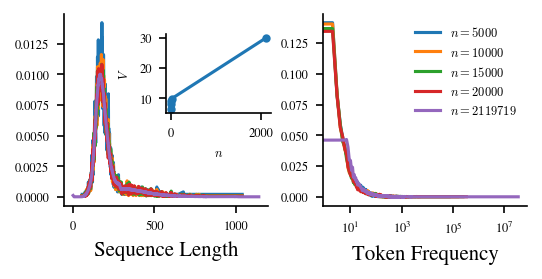

In [48]:
set_font_sizes(conf='tight')
dataset_sizes = np.array( [5000,10000,15000,20000,2119719])

fig , axes = create_fig(ncols=2, h=0.5,sharey=False, sharex=False)

ax = axes[0]
for dataset_size in dataset_sizes:
    lengths = results[dataset_size]['lengths']
    values , counts  = np.unique(lengths, return_counts=True)
    ax.plot(values, counts/len(lengths), label=f'{dataset_size}')
ax.set_xlabel('Sequence Length')

# Insert plot


ax_insert = fig.add_axes([0.3, 0.6, 0.2, 0.3])
voc_sizes = np.array([results[size]['vocab_size'] for size in dataset_sizes])
ax_insert.plot(dataset_sizes/1000, voc_sizes/1000, marker='.')
ax_insert.set_xlabel(r'$n$', fontsize=FONTSIZES['xs'])
ax_insert.set_ylabel(r'$V$', fontsize=FONTSIZES['xs'])
# ax_insert.set_yticks(ax_insert.get_yticks())
# ax_insert.set_yticklabels([f'{int(tick)}k' for tick in ax_insert.get_yticks()])
# ax_insert.set_xticks(ax_insert.get_xticks())
# ax_insert.set_xticklabels([f'{int(tick)}k' for tick in ax_insert.get_xticks()])

ax = axes[1]
for dataset_size in dataset_sizes:
    vocab_distribution = results[dataset_size]['vocab_distribution']
    values , counts  = np.unique(vocab_distribution, return_counts=True)
    ax.plot(values, counts/len(vocab_distribution), label=fr'$n = {dataset_size}$')
ax.set_xlabel('Token Frequency')
# ax.set_ylabel('Frequency')
ax.set_xscale('log')
# ax.set_yscale('log')
ax.legend(frameon=False)


# save_fig(fig,'dataset_stats')

Figure saved on /u/c/cerazova/Transformers/plots as dataset_length_distribution.png


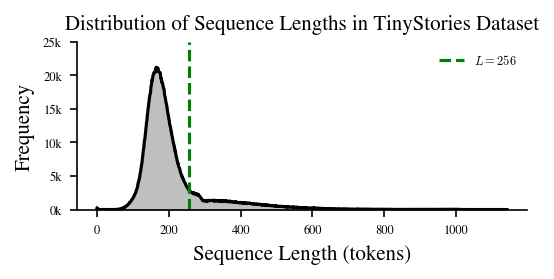

In [51]:
set_font_sizes(conf='tight')
fig , axes = create_fig(h=0.5)

ax = axes 
dataset_size = 2119719
lengths = results[dataset_size]['lengths']
values , counts  = np.unique(lengths, return_counts=True)
ax.plot(values, counts/1000, linestyle='-', color='k')
ax.fill_between(values, 0, counts/1000, color='gray', alpha=0.5)
ax.set_ylim(bottom=0)
ax.set_xlabel('Sequence Length (tokens)')
ax.set_ylabel('Frequency')
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{int(tick)}k' for tick in ax.get_yticks()])
ax.set_title('Distribution of Sequence Lengths in TinyStories Dataset')
ax.axvline(x=256, color='green', linestyle='--', label=r'$L = 256$')
ax.legend(frameon=False)

save_fig(fig,'dataset_length_distribution')

In [ ]:
raw_dataset 

In [ ]:
tokenizer = build_tokenizer(raw_dataset)
vocab_size = tokenizer.get_vocab_size()
print(f'Tokenizer vocabulary size: {vocab_size}')

# Sparsity Measures

Figure saved on /u/c/cerazova/Transformers/plots as sparsity_measures.png


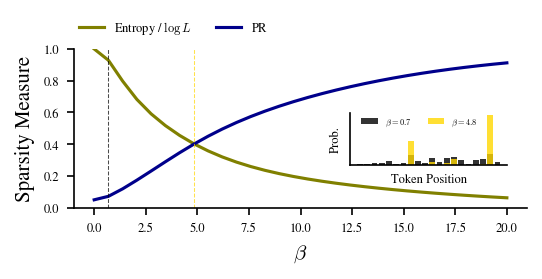

In [65]:
L = 20
n_betas = 30
torch.manual_seed(0)
logits = torch.randn(L).unsqueeze(0)
betas = torch.linspace(0,20,n_betas)
probs = torch.softmax(betas.unsqueeze(1) * logits, dim=1).numpy() # shape (n_betas, L)

# Sparsity measures
entropy = -np.sum(probs * np.log(probs), axis=1) / np.log(L)  # shape (n_betas,)
# ipr = 1 / (L*np.sum(probs**2, axis=1)  ) # shape (n_betas,) 
pr = np.sum(probs**2, axis=1) # participation ratio

# Plots
set_font_sizes(conf='tight')
fig , axes = create_fig()
ax = axes

betas_np = betas.numpy()
ax.plot(betas_np, entropy, label=r'Entropy / $\log L$', color='olive')
ax.plot(betas_np, pr, label=r'PR', color='darkblue')
ax.legend(frameon=False,ncols = 2,loc=(0.,1.05))
ax.set_ylabel(r'Sparsity Measure')
ax.set_xlabel(r'$\beta$')
ax.set_ylim(0,1)
# Insert plot of probs
l , b , w , h = 0.65, 0.4, 0.3, 0.2
inset_ax = fig.add_axes([l, b, w, h])  # [left, bottom, width, height]
# inset_ax.spines['left'].set_visible(False)
inset_ax.set_yticks([])
inset_ax.set_xticks([])
inset_ax.set_xlabel('Token Position',size=FONTSIZES['xs'])
inset_ax.set_ylabel('Prob.',size=FONTSIZES['xs'])
index = [1, 7]
colors = ['k', 'gold']
for i , idx in enumerate(index):
    col = colors[i]
    ax.axvline(betas_np[idx],ymax=1, color=col, linestyle='--', alpha=0.7,lw=0.5)
    inset_ax.bar(np.arange(L), probs[idx], color=col, alpha=0.8, label=fr'$\beta={betas_np[idx]:.1f}$')

inset_ax.legend(frameon=False,ncols=2,loc=(0.05,0.65),fontsize=FONTSIZES['xxs'])

save_fig(fig,'sparsity_measures')




# Evolution Plots

In [40]:
d_model = 528
seq_len = 256
dataset_size=10000

batch_size = 64
lr = 1e-5


fix_names = ['d_model','seq_len','dataset_size']
var_names = ['batch_size','lr']
params = make_params_dict(fix_names , var_names)


summary = load_data('summary',experiment_name='measure_sparcity', params=params)

for key in summary.keys():
    print(f'{key}: {summary[key].shape}')
# print(summary.keys())

File summary_batch_size64_lr1e-05.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/measure_sparcity/d_model528_dataset_size10000_seq_len256
train_loss: (51,)
val_loss: (51,)
train_entropy: (51, 4)
val_entropy: (51, 4)
train_pr: (51, 4)
val_pr: (51, 4)
sequence_fractions: (4,)
evaluation_steps: (51,)
vocab_size: ()


Text(0.5, 0, 'Evaluation Steps')

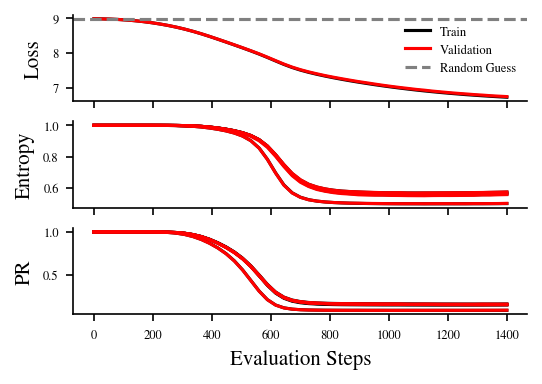

In [42]:

set_font_sizes(conf='tight')
fig , axes = create_fig(nrows=3,h=0.7)

ax = axes[0]

ax.set_ylabel('Loss')
ax.plot(summary['evaluation_steps'], summary['train_loss'], label='Train' , color = 'k')
ax.plot(summary['evaluation_steps'], summary['val_loss'], label='Validation' , color = 'r')
ax.axhline(y=np.log(summary['vocab_size']), color='gray', linestyle='--', label='Random Guess')
ax.legend(frameon=False)    

ax = axes[1]
ax.set_ylabel('Entropy')
ax.plot(summary['evaluation_steps'], summary['train_entropy'], label='Train' , color = 'k')
ax.plot(summary['evaluation_steps'], summary['val_entropy'], label='Validation' , color = 'r')


ax = axes[2]
ax.set_ylabel('PR')
ax.plot(summary['evaluation_steps'], summary['train_pr'], label='Train' , color = 'k')
ax.plot(summary['evaluation_steps'], summary['val_pr'], label='Validation' , color = 'r')
ax.set_xlabel('Evaluation Steps')

# ax.set_xscale('log')


# Full Measurements

In [2]:
d_model = 1024
dataset_size = 30000
seq_len = 256
batch_size = 128
# lr = [0.001,0.01,0.1][2]
lr = 0.05

fix_names = ['d_model','seq_len','dataset_size']
var_names = ['batch_size','lr']
params = make_params_dict(fix_names , var_names)


summary = load_data('summary',experiment_name='full_measurements', params=params)

for key in summary.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary[key].shape}')

File summary_batch_size128_lr0.05.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/full_measurements/d_model1024_dataset_size30000_seq_len256
train_loss: (122,)
val_loss: (122,)
entropy: (122, 5)
part_ratio: (122, 5)
sequence_fractions: (5,)
evaluation_steps: (122,)
vocab_size: ()
embedd_eigvals: (122, 1024)
Wk: (122, 64, 1024)
Wq: (122, 64, 1024)
grad_embedding: (122,)
grad_Wq: (122,)
grad_Wk: (122,)


In [7]:
step = summary['evaluation_steps']
vocab_size = int(summary['vocab_size'])
sequence_fractions = summary['sequence_fractions']
embedd_top_tokens = summary['embedd_top_tokens']
print(f'Seq fractions: {sequence_fractions}')
k = 6
print(f'Tokens aligned with {k}-th top eigvector of embedding covariance matrix:')
for i , toks in enumerate(embedd_top_tokens[::3]):
    print(f'Step {step[::3][i]}: {toks[k]}')
# print(f'Embedd top tokens shape: {embedd_top_tokens}')


Seq fractions: [0.2 0.4 0.6 0.8 1. ]
Tokens aligned with 6-th top eigvector of embedding covariance matrix:
Step 0: ['spread', 'art', 'tick', 'unwanted', 'threaten', 'Marshmallow', 'brighten', 'brambles', 'arrows', 'Megan', 'Abi', 'knocking', 'Yippee', 'Farley', 'kissing', 'surge', 'Peanuts', 'vacuum', 'Girls', 'miracle', 'Eve', 'Tabby', 'tours', 'wanna', 'Mina', 'less', 'grandfather', 'boomed', 'Ed', 'shone']
Step 261: ['"', 'Okay', 'a', 'Hey', 'Hi', 'Sure', 'was', 'Stop', 'and', ',', 'Wow', 'Sorry', 'Please', 'Of', 'Hello', 'No', 'Yes', 'Well', 'Don', 'OK', 'Ow', 'plan', '.', 'Good', 'to', 'Bye', 'Yay', 'Help', 'few', 'Because']
Step 522: ['a', 'few', 'Don', 'and', 'don', 'great', 'such', 'lot', 'to', 'Okay', 'Let', 'Wow', 'Hello', "'", 'couldn', 'Hi', 'was', 'Yes', 'Sure', '"', 'giggled', '€™', 'No', 'plan', 'm', 'met', 'wouldn', 'wasn', 'Stop', 're']
Step 783: ["'", 'couldn', 'm', '€™', 're', 's', 'wouldn', 'didn', 'don', 'wasn', 't', 'll', 'Let', 'and', 'Yes', 'Okay', 'Don', 'Hey'

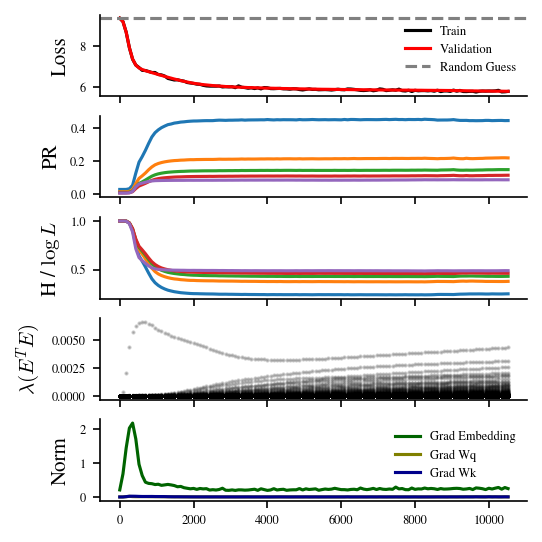

In [29]:


set_font_sizes(conf='tight')
i_seq_frac = -1  # index of sequence fraction to plot
fig , axes = create_fig(nrows=5,h=1)

ax = axes[0]
ax.plot(step,summary['train_loss'], label='Train', color='k')
ax.plot(step,summary['val_loss'], label='Validation', color='r')
ax.axhline(np.log(vocab_size), color='gray', linestyle='--', label='Random Guess')
ax.set_ylabel('Loss')
ax.legend(frameon=False)


ax = axes[1]
ax.plot(step, summary['part_ratio'], label='Validation')
ax.set_ylabel('PR')
# ax.legend(frameon=False)


ax = axes[2]
ax.plot(step, summary['entropy'], label='Validation')
ax.set_ylabel(r'H / $\log L$')
# ax.legend(frameon=False)    



ax = axes[3]
for i , t in enumerate(step):
    ax.scatter([t]*d_model,summary['embedd_eigvals'][i],s=1,alpha=0.2,color='k')

ax.set_ylabel(r'$\lambda(E^T E)$')
# ax.set_yscale('log')

ax = axes[4]
ax.plot(step, summary['grad_embedding'],label='Grad Embedding', color='darkgreen')
ax.plot(step, summary['grad_Wq'],label='Grad Wq', color='olive')
ax.plot(step, summary['grad_Wk'],label='Grad Wk', color='darkblue')
ax.set_ylabel('Norm')
ax.legend(frameon=False)
# ax.set_yscale('log')

# ax.set_xscale('log')
# grad_embedding: (21,)
# grad_Wq: (21,)
# grad_Wk: (21,)


In [10]:
1 + np.sqrt(0.02)

np.float64(1.1414213562373094)

# Write embeddings

In [47]:
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path

log_dir = '../runs/experiment_full_measurements'
# Make sure the log directory exists
Path(log_dir).mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)
write_each = 3
step_embeddings = summary['embeddings_steps'][::write_each]
embeddings = summary['embeddings'][::write_each]  # list of arrays
for i , step in enumerate(step_embeddings):
    emb_matrix = embeddings[i]  # shape (vocab_size, d_model)
    print(i,step, emb_matrix.shape)
    # Log the embeddings to TensorBoard
    writer.add_embedding(mat=emb_matrix, global_step=step, tag='input_embeddings')

0 0 (13249, 1024)
1 1584 (13249, 1024)
2 3168 (13249, 1024)
3 4752 (13249, 1024)


# Others


In [9]:
from attention_nn.model import create_model

In [19]:
params = {'rank':4 , 'd_model':8}
model , device  = create_model(params)
Wk = model.attention_layer.Wk.weight.data.clone().cpu().numpy()
Wk

array([[ 0.03122242,  0.18443088,  0.62467295,  0.08124071, -0.8224753 ,
        -0.4755098 ,  0.41875106, -0.5031421 ],
       [-0.29812658, -0.5380084 , -0.10961679,  0.30405924,  0.09679914,
         0.18725114,  0.23687628, -0.46000022],
       [-0.46447247,  0.01814326, -0.2788878 , -0.07213515, -0.41090468,
         0.8254558 , -0.38503978,  0.38847122],
       [ 0.17959169, -0.28224993, -0.00715496,  0.11889792,  0.3519962 ,
        -0.17765293,  0.42073804,  0.37552217]], dtype=float32)

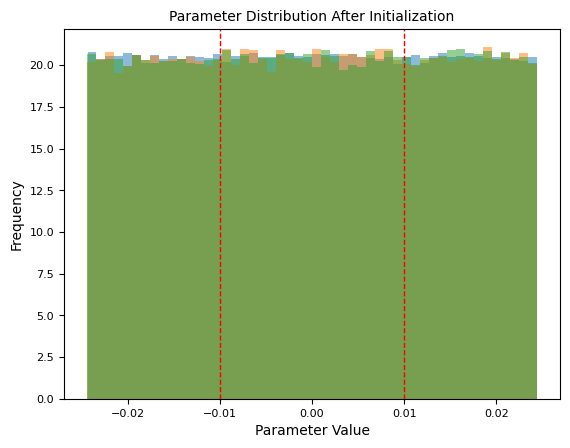

In [18]:
for param in params:
    plt.hist(param.detach().cpu().numpy().flatten(), bins=50, alpha=0.5,density=True)
plt.axvline(1/np.sqrt(model.d_model), color='r', linestyle='dashed', linewidth=1)
plt.axvline(-1/np.sqrt(model.d_model), color='r', linestyle='dashed', linewidth=1)
plt.title('Parameter Distribution After Initialization')
plt.xlabel('Parameter Value')
plt.ylabel('Frequency')
plt.show()